<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Batch Orbit Determination — Complete Demo
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers
This notebook is a **self-contained, verbose walkthrough** of **batch orbit determination (OD)**
using the Scarabaeus framework.  Every concept is explained in detail so that a reader unfamiliar
with the specific Scarabaeus API can follow along.

### Topics
| # | Topic |
|---|-------|
| 1 | Spacecraft model definition |
| 2 | Dynamics model catalogue — all available force models |
| 3 | Dynamics tuning — fidelity vs. cost trade-offs |
| 4 | True trajectory simulation |
| 5 | Measurement generation — Range, Range-Rate, Doppler, DOR, Angular, Centroiding |
| 6 | Reference (perturbed) trajectory |
| 7 | Batch filter — Least-Squares Batch (LSB) |
| 8 | Batch filter — SRIF Batch (SRIFB) + static parameter estimation (η_SRP) |
| 9 | Stochastic acceleration — Piecewise Gauss-Markov (PFOGM) batch OD |
| 10 | Measurement editing — chi-squared and date-range filters |
| 11 | Saving the OD solution |
| 12 | Solution analysis — covariance propagation, state extraction |

## How to run
Run cells top-to-bottom from the **project root** directory (`scarabaeus/`).
The first code cell will navigate there automatically if you opened the notebook from `tutorials/`.


## 0. Imports and Setup

We begin by importing Scarabaeus and the standard scientific stack, then establishing the working
directory, loading SPICE kernels, and defining the unit/frame system.

### Units
Scarabaeus uses a dimensional unit system.  `scb.Units.get_units()` returns unit objects that can
be composed with `*`, `/`, and `**` operators.  Every numerical quantity is wrapped in
`ArrayWUnits` so that unit consistency is enforced throughout the computation.

### Frames
Reference frames are managed via SPICE.  `J2000` is the standard inertial frame used for
heliocentric OD.

### SPICE kernels
The meta-kernel `locked_generic.tm` loads planet ephemerides (DE440), leap-seconds, planetary
constants, and Earth ground-station SPKs (DSS-14, DSS-63, etc.).


In [1]:
import os, sys
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt

import scarabaeus as scb

# ── working directory ────────────────────────────────────────────
# Notebooks live in tutorials/; data paths are relative to project root.
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
print(f"Working directory : {os.getcwd()}")

# ── ensure output directories exist ─────────────────────────────
os.makedirs('data/measurements/radiometric', exist_ok=True)
os.makedirs('data/kernels/scenario',         exist_ok=True)

# ── units ────────────────────────────────────────────────────────
kg, km, sec = scb.Units.get_units(['kg', 'km', 'sec'])

# ── frames ───────────────────────────────────────────────────────
J2000, ITRF93, ECLIPJ2000, IAUEARTH = scb.Frame.generate_common_frames()
frame = J2000

# ── SPICE kernels ─────────────────────────────────────────────────
mk = os.path.join('data', 'kernels', 'locked', 'locked_generic.tm')
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(mk)
print("Kernels loaded.")


Working directory : /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections


SpiceNOSUCHFILE: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(NOSUCHFILE) --

The first file '../data/kernels/locked/ck/cas00084.tsc' specified by KERNELS_TO_LOAD in the file data/kernels/locked/locked_generic.tm could not be located.

furnsh_c --> FURNSH --> ZZLDKER

================================================================================

## Enhanced Plotting Helpers

The cells below add **calendar-date x-axis** versions of the plots above, plus new
visualization types: pre/post residual comparisons, state errors with ±3σ covariance
bounds, covariance evolution, and corner covariance plots.

Helper functions:
- `et2dt(et_arr)` — converts SPICE ET (seconds) to Python `datetime` objects
- `fmt_cal(ax)` — applies `AutoDateLocator + DateFormatter` for a clean calendar x-axis
- `add_hrs_axis(ax)` — adds a secondary top x-axis in hours from t0
- `resid_from_filter(flt, ds)` — extracts `(t_pre, r_pre, t_post, r_post)` arrays
- `corner_cov(P, labels)` — lower-triangle corner plot with RdBu_r correlation colouring


In [2]:
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})
CMAP = cm.tab10
COLORS = [CMAP(i / 10) for i in range(10)]

# reference epoch for the hours-from-t0 secondary axis
t0_et = None  # set after epoch_array is defined (run spacecraft/epoch setup cell first)


def et2dt(et_arr):
    """Convert SPICE ET seconds (TDB from J2000) to list of datetime objects."""
    _J2000 = datetime(2000, 1, 1, 12, 0, 0)
    return [_J2000 + timedelta(seconds=float(t)) for t in np.atleast_1d(et_arr)]


def fmt_cal(ax):
    """Apply calendar-date tick formatting to a matplotlib axis."""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))


def add_hrs_axis(ax, t0=None):
    """Add a secondary top x-axis showing hours from t0."""
    t0 = t0 if t0 is not None else t0_et
    from matplotlib.dates import date2num
    t0_num = date2num(et2dt([t0])[0])
    ax2 = ax.secondary_xaxis(
        "top",
        functions=(lambda x: (x - t0_num) * 24, lambda x: x / 24 + t0_num),
    )
    ax2.set_xlabel("Hours from t0 [TDB]", fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f h"))
    return ax2


def resid_from_filter(flt_obj, ds_name):
    """Return (t_pre, r_pre, t_post, r_post) numpy arrays for a dataset name.

    Times are read from flt_obj.measurement_data (per-dataset t2 column).
    Residual values come from the [res, sigma] entries in pre/postfit_residuals.
    """
    pre  = flt_obj.prefit_residuals.get(ds_name, [])
    post = flt_obj.postfit_residuals.get(ds_name, [])
    # Retrieve t2 epochs for this dataset from the filter's measurement data
    t_ds = np.array([])
    for ds in flt_obj.measurement_data.datasets:
        if ds.set_name == ds_name:
            t_ds = np.array(ds.data["t2"])
            break
    t_pre  = t_ds[:len(pre)]  if len(pre)  else np.array([])
    r_pre  = np.array([d[0] for d in pre])  if pre  else np.array([])
    t_post = t_ds[:len(post)] if len(post) else np.array([])
    r_post = np.array([d[0] for d in post]) if post else np.array([])
    return t_pre, r_pre, t_post, r_post


def corner_cov(P, labels, title="Covariance Corner Plot", figsize=(10, 9)):
    """
    Corner plot from a covariance matrix.
    Diagonal: 1D Gaussian marginal (dark-shaded ±1σ region).
    Lower triangle: 2D confidence ellipses at 1σ / 2σ / 3σ  (chi2, 2 dof).
    Upper triangle: hidden.
    """
    from matplotlib.patches import Ellipse

    # sqrt(chi2.ppf(conf, df=2)) for 1σ / 2σ / 3σ 2D confidence
    SCALES = [1.5150, 2.4477, 3.4395]
    ALPHAS = [0.55,   0.30,   0.15  ]
    COL, EDG = 'steelblue', 'navy'

    n   = P.shape[0]
    sig = np.sqrt(np.diag(P))

    fig, axes = plt.subplots(n, n, figsize=figsize,
                             gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
    if n == 1:
        axes = np.array([[axes]])
    fig.suptitle(title, fontsize=11, fontweight='bold')

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            ax.tick_params(labelsize=5)

            if i == j:
                # ── diagonal: 1D Gaussian marginal ──────────────────────
                s   = sig[i]
                lim = 3.8 * s
                x   = np.linspace(-lim, lim, 300)
                y   = np.exp(-0.5 * (x / s) ** 2)

                ax.plot(x, y, color=COL, lw=1.5)
                ax.fill_between(x, y, alpha=0.18, color=COL)
                ax.fill_between(x[np.abs(x) <= s], y[np.abs(x) <= s],
                                alpha=0.45, color=COL)   # shade ±1σ
                ax.axvline(0, color='k', lw=0.5, ls='--')
                ax.set_xlim(-lim, lim)
                ax.set_ylim(0, 1.30)
                ax.set_yticks([])
                ax.set_xticks([-2*s, 0, 2*s])
                ax.text(0.97, 0.97, f'1σ={s:.2e}',
                        transform=ax.transAxes, fontsize=6,
                        ha='right', va='top', color=EDG, fontweight='bold')
                ax.set_title(labels[i], fontsize=7, pad=2)
                if i < n - 1:
                    ax.set_xticklabels([])

            elif i > j:
                # ── lower triangle: 2D confidence ellipses ───────────────
                P2      = np.array([[P[j,j], P[j,i]], [P[i,j], P[i,i]]])
                ev, evec = np.linalg.eigh(P2)
                ev      = np.maximum(ev, 0.0)
                angle   = np.degrees(np.arctan2(evec[1, 1], evec[0, 1]))

                ax.axhline(0, color='k', lw=0.4, ls='--', alpha=0.4)
                ax.axvline(0, color='k', lw=0.4, ls='--', alpha=0.4)

                for scale, alpha in zip(SCALES, ALPHAS):
                    ax.add_patch(Ellipse(
                        xy=(0, 0),
                        width =2 * scale * np.sqrt(ev[1]),
                        height=2 * scale * np.sqrt(ev[0]),
                        angle =angle,
                        facecolor=COL, edgecolor=EDG,
                        linewidth=0.8, alpha=alpha,
                    ))

                rho = P[i, j] / (sig[i] * sig[j])
                ax.text(0.05, 0.97, f'ρ={rho:+.2f}',
                        transform=ax.transAxes, fontsize=6.5,
                        color=EDG, va='top', fontweight='bold')

                ax.set_xlim(-3.8*sig[j], 3.8*sig[j])
                ax.set_ylim(-3.8*sig[i], 3.8*sig[i])
                ax.set_xticks([-2*sig[j], 0, 2*sig[j]])
                ax.set_yticks([-2*sig[i], 0, 2*sig[i]])

                if i < n - 1:
                    ax.set_xticklabels([])
                if j > 0:
                    ax.set_yticklabels([])
                if j == 0:
                    ax.set_ylabel(labels[i], fontsize=7, labelpad=2)
                if i == n - 1:
                    ax.set_xlabel(labels[j], fontsize=7, labelpad=2)

            else:
                ax.set_visible(False)

    plt.tight_layout()
    return fig


print("Plotting helpers ready.  (t0 will be set after epoch_array is defined)")


Plotting helpers ready.  (t0 will be set after epoch_array is defined)


## 1. Spacecraft Model

A `Spacecraft` object encodes the physical properties of the vehicle:

| Property | Description |
|----------|-------------|
| `name` | Human-readable label (also used as SPICE body name) |
| `spice_id` | NAIF integer ID (negative integers are spacecraft) |
| `tot_mass` | Total wet mass [kg] |
| `area` | Cross-sectional area for SRP [km²] |
| `ref_coeff` | Reflectivity coefficient C_r (dimensionless) |
| `n_plate_model` | Optional: N-plate SRP model for attitude-dependent SRP |

For the **"truth" simulation** we define `Orbiter` and for each **filter iteration** we create a
separate spacecraft object with a slightly different SPICE ID, so that SPICE kernel writes for the
reference trajectory do not clash.


In [3]:
# ── physical properties ──────────────────────────────────────────
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)          # ~10 m²
cr        = scb.ArrayWUnits(1.5,    None)            # reflectivity (dimensionless)

# ── truth spacecraft ─────────────────────────────────────────────
Orbiter = scb.Spacecraft(
    name     = 'Orbiter_True',
    spice_id = -1000,
    tot_mass = dry_mass + fuel_mass,
    area     = area,
    ref_coeff= cr,
)

# ── gravitational origin ─────────────────────────────────────────
# Heliocentric orbit: Sun is the primary attracting body.
origin = scb.CelestialBody.from_constants('SUN')

# ── time window ──────────────────────────────────────────────────
# 3-day tracking arc with 30-min timesteps (good balance of coverage vs. cost)
time_0     = scb.SpiceManager.jd2et(2461809.72995654 + 1/3)  # start JD → ET
time_f     = scb.SpiceManager.jd2et(2461809.72995654 + 3)    # end   JD → ET
dt_step    = 30 * 60                                           # 30 minutes [s]
epoch_array = scb.EpochArray(np.arange(time_0, time_f, dt_step), sys='TDB')
epoch_0     = epoch_array[0]
print(f"Arc start : {scb.SpiceManager.et2utc(float(epoch_array[0].times.values))} UTC")
print(f"Arc end   : {scb.SpiceManager.et2utc(float(epoch_array[-1].times.values))} UTC")
print(f"N epochs  : {len(epoch_array)}")

# ── initial state (heliocentric J2000) ────────────────────────────
# Near-Earth heliocentric orbit (position ~1 AU from Sun)
pos_0 = scb.ArrayWFrame(
    np.array([-1.1123095885148e+08,  8.9094345479316e+07,  3.8656500948069e+07]), km, frame)
vel_0 = scb.ArrayWFrame(
    np.array([-20.6936999825159, -16.7800270812616, -6.6437327193572]), km/sec, frame)

print(f"\nInitial position magnitude : {np.linalg.norm(pos_0.quantity.values):.3e} km")
print(f"Initial velocity magnitude : {np.linalg.norm(vel_0.quantity.values):.6f} km/s")
t0_et = float(epoch_array[0].times.values)  # used by plotting helpers


SpiceMISSINGTIMEINFO: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(MISSINGTIMEINFO) --

The following variables, needed to convert between the input uniform time scales, were not found in the kernel pool: DELTET/DELTA_T_A, DELTET/K, DELTET/EB, DELTET/M. Your program may have failed to load a leapseconds kernel. Other possible causes of this problem include loading an invalid leapseconds kernel---one that lacks an initial \begindata marker or final newline character, or is otherwise corrupted---or deleting previously loaded kernel pool variables via calls to routines that clear the kernel pool.

unitim_c --> UNITIM

================================================================================

## 2. Dynamics Models Catalogue

Scarabaeus provides a **modular force model system** through `ForceModelTranslation`.
You turn on each perturbation with keyword flags.  This section documents every available option.

---

### 2.1 Point Mass Gravity (Keplerian)
The simplest model: the spacecraft is attracted only by the central body (Sun in our case).
No keyword needed — this is always included.

```python
fm = scb.ForceModelTranslation(primary_body=sc)
```

**When to use:** quick propagation checks, very short arcs, or when perturbations are negligible.

---

### 2.2 Third-Body Gravity
Gravitational pull from other solar-system bodies (planets, Moon, etc.).
Pass a list of SPICE body names.

```python
fm = scb.ForceModelTranslation(primary_body=sc,
                               third_bodies=['EARTH', 'JUPITER BARYCENTER', ...])
```

**Effect:** at 1 AU from the Sun, Earth and Jupiter perturbations are on the order of 10⁻⁶ km/s²
over a 3-day arc — significant for precision OD.

---

### 2.3 Cannonball Solar Radiation Pressure (SRP)
Isotropic SRP model.  Uses `area` and `ref_coeff` from the Spacecraft object.
The SRP scale factor η_SRP can be estimated as a static parameter in the OD state.

```python
fm = scb.ForceModelTranslation(primary_body=sc, cannonball_SRP=True)
```

**When to use:** missions without attitude data, or as a first-order SRP estimate.

---

### 2.4 N-Plate SRP
Attitude-dependent SRP computed face-by-face from a plate configuration file.
Requires a CK (attitude) kernel and an n-plate config JSON.

```python
fm = scb.ForceModelTranslation(primary_body=sc, nplate_SRP=True)
```

**When to use:** high-fidelity SRP for spacecraft with known CK.

---

### 2.5 Spherical Harmonics Gravity
Non-spherical gravity field from a Stokes coefficients file.
Used for close-proximity or planetary orbits.

```python
fm = scb.ForceModelTranslation(
    primary_body     = sc,
    sph_harm         = True,
    sph_harm_order   = 8,                          # degree & order
    sph_harm_cs_file = 'data/dynamic_setup/sph_coefficients/Earth_100.json',
    sph_harm_body    = scb.EARTH,
    sph_harm_norm_flag = True,                     # normalized coefficients
)
```

**When to use:** Earth orbits, asteroid proximity operations.

---

### 2.7 First-Order Gauss-Markov (FOGM) Stochastic Acceleration
An exponentially correlated random acceleration — ideal for modelling uncharacterised
non-gravitational forces.

```python
fm = scb.ForceModelTranslation(
    primary_body           = sc,
    first_order_gauss_markov = True,
    fogm_beta              = np.array([1/3600, 1/3600, 1/3600]),  # [1/s] correlation = 1 hr
)
# State must include the FOGM acceleration as a *dynamic* parameter:
# .param('a_fogm', sc, a0_vec3, dynamics='dynamic')
```

---

### 2.8 Piecewise First-Order Gauss-Markov (PFOGM)
Like FOGM but the stochastic acceleration is defined within each batch interval.
Useful for batch OD where you want piece-wise unmodelled force estimation.

```python
batch_length = 6 * 3600   # 6-hour batches
n_batches    = int(np.ceil((time_f - time_0) / batch_length))

fm = scb.ForceModelTranslation(
    primary_body                  = sc,
    piecewise_first_order_gauss_markov = True,
    pfogm_batch_length            = batch_length,
    pfogm_n_batches               = n_batches,
    pfogm_beta                    = np.array([1/3600, 1/3600, 1/3600]),
    t0                            = epoch_array[0],
)
# State must include: .param('a_pfogm', sc, a0_vec_3n, dynamics='dynamic')
# where a0_vec_3n has 3 * n_batches elements.
```


## 3. Dynamics Tuning

**Dynamics tuning** means choosing which force models to include and verifying their fidelity
against an independent truth (SPICE ephemerides or higher-fidelity propagation).

### Workflow
1. Propagate the trajectory using both model A (low fidelity) and model B (high fidelity).
2. Compute the trajectory differences over the estimation arc.
3. Compare these differences against the expected measurement noise or OD accuracy level.
4. If the discrepancies are comparable to or larger than the observable noise floor, model A is likely insufficient.

### Process noise tuning
When using sequential filters (discussed in the next notebook), the continuous-time process noise covariance **Q** (or equivalently its power spectral density, PSD) must be carefully tuned:

- Too large **Q** → the filter becomes noisy, over-fits the measurements, and produces inflated covariances.
- Too small **Q** → the filter becomes overconfident, potentially inconsistent, and may diverge as unmodelled accelerations accumulate over time.


In [4]:
# ── compare Keplerian vs 3-body vs full model ────────────────────

third_bodies_all = ['MERCURY', 'VENUS', 'EARTH', 'MARS', 'JUPITER BARYCENTER']

def propagate_model(sc_body, pos, vel, epoch_arr, **fm_kwargs):
    state_def = scb.StateDefinition.from_components([
        ('position', 3, 'estimated', 'dynamic', sc_body, pos),
        ('velocity', 3, 'estimated', 'dynamic', sc_body, vel),
    ])
    sv = scb.StateArray(epoch=epoch_arr[0], origin=origin, state=state_def)
    fm = scb.ForceModelTranslation(primary_body=sc_body, **fm_kwargs)
    prop = scb.Propagator(primary_body=sc_body, state_vector=sv,
                          tspan=epoch_arr, force_models=fm)
    prop.propagate()
    pos_arr = prop.propagated_state_array.values_array[('position', sc_body.spice_id)][0]
    return pos_arr   # shape (N, 3)

# Use a shorter window for tuning comparison (faster)
tune_end    = scb.SpiceManager.jd2et(2461809.72995654 + 1/3 + 1)  # 1-day arc
epoch_tune  = scb.EpochArray(np.arange(time_0, tune_end, dt_step), sys='TDB')

# Keplerian helper SC (unique SPICE ID to avoid conflicts)
sc_kep  = scb.Spacecraft('tune_kep',  -1090, dry_mass+fuel_mass, area, cr)
sc_3b   = scb.Spacecraft('tune_3b',   -1091, dry_mass+fuel_mass, area, cr)
sc_full = scb.Spacecraft('tune_full', -1092, dry_mass+fuel_mass, area, cr)

print("Propagating Keplerian ...")
pos_kep  = propagate_model(sc_kep,  pos_0, vel_0, epoch_tune)
print("Propagating 3-body ...")
pos_3b   = propagate_model(sc_3b,   pos_0, vel_0, epoch_tune,
                            third_bodies=['EARTH', 'VENUS'])
print("Propagating 3-body + cannonball SRP ...")
pos_full = propagate_model(sc_full, pos_0, vel_0, epoch_tune,
                            third_bodies=['EARTH', 'VENUS'], cannonball_SRP=True)

t_hr = (epoch_tune.times.values - epoch_tune.times.values[0]) / 3600

err_3b   = np.linalg.norm(pos_3b   - pos_kep,  axis=1)   # 3-body vs Keplerian
err_full = np.linalg.norm(pos_full - pos_3b,   axis=1)   # SRP effect on top of 3-body

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].semilogy(t_hr, err_3b,   'b-', lw=1.5, label='3-body − Keplerian')
axes[0].set_ylabel('Position diff [km]')
axes[0].set_title('Dynamics Tuning: effect of each force model (1-day arc)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].semilogy(t_hr, err_full, 'r-', lw=1.5, label='(3-body+SRP) − 3-body')
axes[1].set_ylabel('Position diff [km]')
axes[1].set_xlabel('Time [hr]')
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"\nMax position difference (3-body vs Keplerian)  : {err_3b.max():.4f} km")
print(f"Max position difference (SRP effect on 3-body) : {err_full.max():.6f} km")


SpiceMISSINGTIMEINFO: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(MISSINGTIMEINFO) --

The following variables, needed to convert between the input uniform time scales, were not found in the kernel pool: DELTET/DELTA_T_A, DELTET/K, DELTET/EB, DELTET/M. Your program may have failed to load a leapseconds kernel. Other possible causes of this problem include loading an invalid leapseconds kernel---one that lacks an initial \begindata marker or final newline character, or is otherwise corrupted---or deleting previously loaded kernel pool variables via calls to routines that clear the kernel pool.

unitim_c --> UNITIM

================================================================================

## 4. True Trajectory Generation

We propagate the **true trajectory** using the highest-fidelity force model available.
This trajectory is saved as a SPICE SPK kernel so it can be queried later for ground truth
comparisons and measurement generation.

The `Trajectory` object wraps the propagated state array and provides:
- `write_to_spk(path)` — write binary SPK kernel
- `start_epoch`, `end_epoch` — arc boundaries

In real operations the "truth" is unknown; here we simulate it to validate the OD solution.


In [5]:
# ── force model for truth propagation ────────────────────────────
# Use 3-body gravity + cannonball SRP as the "truth" dynamics.
# The OD filter will use the same model (ideal case) — in Section 8 we perturb η_SRP.
fm_truth = scb.ForceModelTranslation(
    primary_body  = Orbiter,
    third_bodies  = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP= True,
)

state_0_truth = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter, pos_0),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter, vel_0),
])
sv_truth = scb.StateArray(epoch=epoch_0, origin=origin, state=state_0_truth)

prop_truth = scb.Propagator(
    primary_body = Orbiter,
    state_vector = sv_truth,
    tspan        = epoch_array,
    force_models = fm_truth,
)
print("Propagating true trajectory ...")
prop_truth.propagate()
state_prop_truth = prop_truth.propagated_state_array

# ── save as SPICE SPK ─────────────────────────────────────────────
true_spk = 'data/kernels/scenario/batch_orbiter_true.bsp'
if os.path.isfile(true_spk):
    os.remove(true_spk)
orbiter_traj_true = scb.Trajectory(state_array=state_prop_truth)
orbiter_traj_true.write_to_spk(true_spk)
print(f"True trajectory saved to: {true_spk}")


NameError: name 'pos_0' is not defined

## 5. Measurement Generation

Scarabaeus models all standard radiometric and optical navigation measurement types.
This section shows how to set up each model, simulate noisy observations on the true
trajectory, save them to JSON files, and reload them for OD use. For real mission measurements, refer to the OSIRIS–REx notebooks.

### Measurement generation workflow
```
Spacecraft trajectory (true SPK)
        │
        ▼
write_observed_measurements(target, epoch_array, noisy=True, file_name=stem)
        │   adds Gaussian noise with the specified sigma
        ▼
JSON file in data/measurements/radiometric/
        │
        ▼
observed_measurements(file_name, meas_name, units) → (epoch_array, times_sec, values)
```

### Available measurement types
| Class | Observable | Typical sigma |
|-------|-----------|---------------|
| `RangeIdeal` | Two-way range [km] | 1 m (1e-3 km) |
| `RangeRateIdeal` | Two-way range-rate [km/s] | 0.1 mm/s (1e-4 km/s) |
| `AngularIdeal` | RA/DEC [rad] | ~10 μrad |
| `CentroidingIdeal` | Pixel centroid [pixel] | 0.5–2 pixel |
| `SequentialRangingReal` | Sequential ranging (RU) | see DSN calibration |
| `DopplerReal` | Doppler (DSN processing) | see DSN calibration |


In [6]:
# ─────────────────────────────────────────────────────────────────
# 5.1  Ground-station sensors
# ─────────────────────────────────────────────────────────────────
# GroundStation wraps a SPICE-body ground station.
# DSS-14 (Goldstone, CA) and DSS-63 (Madrid) are built into the generic kernel.
GS1 = scb.GroundStation('DSS-14')
GS2 = scb.GroundStation('DSS-63')

# ─────────────────────────────────────────────────────────────────
# 5.2  Measurement noise levels
# ─────────────────────────────────────────────────────────────────
range_sigma     = scb.ArrayWUnits(1e-3,  km)           # 1 m two-way range
rangerate_sigma = scb.ArrayWUnits(1e-7,  km/sec)       # 0.1 mm/s range-rate

# ─────────────────────────────────────────────────────────────────
# 5.3  Instantiate all measurement models
# ─────────────────────────────────────────────────────────────────

# ── Radiometric: Range ───────────────────────────────────────────
Range_GS1     = scb.RangeIdeal('GS1 Range',     GS1,  sigma=range_sigma)
Range_GS2     = scb.RangeIdeal('GS2 Range',     GS2,  sigma=range_sigma)

# ── Radiometric: Range-Rate ──────────────────────────────────────
RangeRate_GS1 = scb.RangeRateIdeal('GS1 RangeRate', GS1, sigma=rangerate_sigma)
RangeRate_GS2 = scb.RangeRateIdeal('GS2 RangeRate', GS2, sigma=rangerate_sigma)


print("All measurement models instantiated.")
print(f"  Range_GS1     : {Range_GS1.name}")
print(f"  RangeRate_GS1 : {RangeRate_GS1.name}")


All measurement models instantiated.
  Range_GS1     : GS1 Range
  RangeRate_GS1 : GS1 RangeRate


In [7]:
# ─────────────────────────────────────────────────────────────────
# 5.4  Generate and save observed (noisy) measurements
# ─────────────────────────────────────────────────────────────────
# check_visibility=True filters out epochs where the spacecraft
# is below the ground station elevation mask (default 10°), producing
# realistic contact windows instead of continuous coverage.

for model, stem in [
    (Range_GS1,      'batch_range_GS1'),
    (RangeRate_GS1,  'batch_rangerate_GS1'),
    (Range_GS2,      'batch_range_GS2'),
    (RangeRate_GS2,  'batch_rangerate_GS2'),
]:
    model.write_observed_measurements(
        target           = Orbiter,
        epoch_array      = epoch_array,
        noisy            = True,
        file_name        = stem,
        check_visibility = True,
        elevation_mask   = 10.0,
    )
    print(f"Written: {stem}.json")

# ─────────────────────────────────────────────────────────────────
# 5.5  Load back the primary measurements (GS1 Range + RangeRate)
# ─────────────────────────────────────────────────────────────────
obs_range_GS1 = Range_GS1.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_range_GS1.json',
    meas_name = 'meas_ideal',
    units     = km,
)
obs_rr_GS1 = RangeRate_GS1.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_rangerate_GS1.json',
    meas_name = 'meas_ideal',
    units     = km/sec,
)
obs_range_GS2 = Range_GS2.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_range_GS2.json',
    meas_name = 'meas_ideal',
    units     = km,
)
obs_rr_GS2 = RangeRate_GS2.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_rangerate_GS2.json',
    meas_name = 'meas_ideal',
    units     = km/sec,
)

# Tuple layout: (epoch_array, times_sec, values_array)
print(f"\nGS1 Range     — {len(obs_range_GS1[2].quantity.values)} measurements")
print(f"GS1 RangeRate — {len(obs_rr_GS1[2].quantity.values)} measurements")
print(f"GS2 Range     — {len(obs_range_GS2[2].quantity.values)} measurements")
print(f"GS2 RangeRate — {len(obs_rr_GS2[2].quantity.values)} measurements")


NameError: name 'epoch_array' is not defined

In [8]:
# ─────────────────────────────────────────────────────────────────
# 5.6  Plot the simulated measurements
# ─────────────────────────────────────────────────────────────────
# Use the EpochArray (obs[0]) for absolute ET → calendar dates so all panels
# share the same time axis and contact windows appear as distinct clusters.

def meas_dts(obs_tuple):
    """Return datetime list from a measurement tuple's EpochArray."""
    _J2000 = datetime(2000, 1, 1, 12, 0, 0)
    et_vals = np.atleast_1d(obs_tuple[0].times.values).astype(float)
    return [_J2000 + timedelta(seconds=float(t)) for t in et_vals]

dts_rng_GS1 = meas_dts(obs_range_GS1)
dts_rng_GS2 = meas_dts(obs_range_GS2)
dts_rr_GS1  = meas_dts(obs_rr_GS1)
dts_rr_GS2  = meas_dts(obs_rr_GS2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')

# Range GS1
axes[0,0].plot(dts_rng_GS1, obs_range_GS1[2].quantity.values, '.', ms=4, label='DSS-14 (GS1)')
axes[0,0].set_title('Two-Way Range — DSS-14'); axes[0,0].set_ylabel('Range [km]')
axes[0,0].legend(); fmt_cal(axes[0,0])

# Range GS2
axes[0,1].plot(dts_rng_GS2, obs_range_GS2[2].quantity.values, '.', ms=4, color='C1', label='DSS-63 (GS2)')
axes[0,1].set_title('Two-Way Range — DSS-63'); axes[0,1].set_ylabel('Range [km]')
axes[0,1].legend(); fmt_cal(axes[0,1])

# RangeRate GS1
axes[1,0].plot(dts_rr_GS1, obs_rr_GS1[2].quantity.values, '.', ms=4, label='DSS-14 (GS1)')
axes[1,0].set_title('Range-Rate — DSS-14'); axes[1,0].set_ylabel('Range-rate [km/s]')
axes[1,0].legend(); fmt_cal(axes[1,0])

# RangeRate GS2
axes[1,1].plot(dts_rr_GS2, obs_rr_GS2[2].quantity.values, '.', ms=4, color='C1', label='DSS-63 (GS2)')
axes[1,1].set_title('Range-Rate — DSS-63'); axes[1,1].set_ylabel('Range-rate [km/s]')
axes[1,1].legend(); fmt_cal(axes[1,1])

n_r1  = len(obs_range_GS1[2].quantity.values)
n_r2  = len(obs_range_GS2[2].quantity.values)
n_rr1 = len(obs_rr_GS1[2].quantity.values)
n_rr2 = len(obs_rr_GS2[2].quantity.values)
plt.suptitle(
    f'Simulated Radiometric Measurements — Batch OD Demo\n'
    f'(Range: {n_r1} GS1 + {n_r2} GS2 pts;  Range-Rate: {n_rr1} GS1 + {n_rr2} GS2 pts)',
    fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


NameError: name 'obs_range_GS1' is not defined

## 6. Reference Trajectory (Perturbed Initial Conditions)

In real OD we do not know the true initial state; we start from a **reference trajectory**
obtained from a previous solution or orbit determination arc, then apply the filter to correct it.

Here we simulate this by **perturbing** the true initial state:
- Position: ±1 km error (typical for deep-space missions after several days without tracking)
- Velocity: ±1 mm/s error

The filter's job is to recover the deviation `δx = x_true − x_ref` at each measurement epoch.

Each filter iteration uses a **new Spacecraft object** (unique SPICE ID) so that its SPK kernel
does not overwrite the truth or previous iteration's kernel.

### Covariance initialisation
The **initial covariance matrix P₀** encodes our uncertainty in the reference initial state.
Rule of thumb: set the 1-σ values to roughly the size of the perturbation.


In [9]:
# ── perturb initial state ─────────────────────────────────────────
delta_pos_km  = np.array([1.0, 1.0, 1.0])       # 1 km position error in each axis
delta_vel_kms = np.array([1e-3, 1e-3, 1e-3])    # 1 mm/s velocity error in each axis

delta_pos = scb.ArrayWUnits(delta_pos_km,  km)
delta_vel = scb.ArrayWUnits(delta_vel_kms, km/sec)

pos_ref = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ref = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

# ── reference spacecraft (iteration 1) ───────────────────────────
Orbiter_ref = scb.Spacecraft('Orbiter_Ref_it1', -1001,
                              dry_mass+fuel_mass, area, cr)

state_ref = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter_ref, pos_ref),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter_ref, vel_ref),
])
sv_ref = scb.StateArray(epoch=epoch_0, origin=origin, state=state_ref)

# ── propagate reference with same force model as truth ───────────
fm_ref = scb.ForceModelTranslation(
    primary_body   = Orbiter_ref,
    third_bodies   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP = True,
)
prop_ref = scb.Propagator(
    primary_body = Orbiter_ref,
    state_vector = sv_ref,
    tspan        = epoch_array,
    force_models = fm_ref,
)

# ── initial covariance P₀ ────────────────────────────────────────
# Set 1-σ to ~3× the perturbation (conservative initialisation)
pos_sig = scb.ArrayWUnits(3 * delta_pos_km[0], km)
vel_sig = scb.ArrayWUnits(3 * delta_vel_kms[0], km/sec)
state_cov = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig],
    epoch_array[1],
    from_list=True,
)
print("Reference trajectory and P₀ ready.")
print(f"  Position 1-σ : {3*delta_pos_km[0]:.1f} km")
print(f"  Velocity 1-σ : {3*delta_vel_kms[0]:.4f} km/s")


NameError: name 'pos_0' is not defined

## 7. Batch Filter: Least-Squares Batch (LSB)

### Theory
The Least-Squares Batch (LSB) filter solves the normal equations

$$\mathbf{x}^* = \left(\mathbf{H}^T \mathbf{W} \mathbf{H} + \mathbf{P}_0^{-1}\right)^{-1}
  \mathbf{H}^T \mathbf{W} \mathbf{y}$$

where **H** is the measurement sensitivity matrix, **W = R⁻¹** is the measurement weight matrix,
**y** are the pre-fit residuals, and **P₀** is the initial state covariance (acts as a Tikhonov
regulariser).

The solution is computed iteratively: after each batch solve, the reference trajectory is updated and the process repeats until

$$
\|\delta x\| < \texttt{convergence\_threshold}
$$

or until the maximum number of iterations is reached.

### Measurement specification
`MeasurementSpec.many()` or `MeasurementSpec.from_dict()` combine multiple measurement datasets
into the single structure the filter expects.

### FilterSettings
`FilterSettings` gathers all configuration:
- `initial_covariance` — P₀
- `process_noise` — `ProcessNoiseSettings` (batch filters: usually not used; sequential: SNC/DMC)
- `output` — `OutputSettings` for controlling what is saved


In [10]:
# ── measurement list ────────────────────────────────────────────
meas_list_lsb = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range_GS1,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr_GS1,
                        dataset_name='GS1 RangeRate'),
    scb.MeasurementSpec(model=Range_GS2,     observed_meas=obs_range_GS2,
                        dataset_name='GS2 Range'),
    scb.MeasurementSpec(model=RangeRate_GS2, observed_meas=obs_rr_GS2,
                        dataset_name='GS2 RangeRate'),
)

# ── filter settings ──────────────────────────────────────────────
settings_lsb = scb.FilterSettings(
    initial_covariance = state_cov,
    output = scb.OutputSettings(
        metadata = {'version': '1.0', 'filter': 'LSB', 'arc': '3-day'},
    ),
)

# ── instantiate LSB filter ───────────────────────────────────────
# LSB = Least-Squares Batch.
# traj_name: SPK filename for the reference trajectory of this iteration.
ref_spk_lsb = 'data/kernels/scenario/batch_orbiter_ref_lsb.bsp'
if os.path.isfile(ref_spk_lsb): os.remove(ref_spk_lsb)

lsb = scb.LSB(
    propagator   = prop_ref,
    settings     = settings_lsb,
    measurements = meas_list_lsb,
    traj_name    = 'batch_orbiter_ref_lsb.bsp',
)

# ── run the batch solver ─────────────────────────────────────────
print("Running LSB batch filter ...")
solution_lsb, n_iters_lsb, converged_lsb = lsb.fit(
    max_iterations       = 10,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'batch_orbiter_ref.bsp',
)
print(f"\nConverged: {converged_lsb}  after {n_iters_lsb} iteration(s)")


NameError: name 'obs_range_GS1' is not defined

In [11]:
# ── LSB — estimated trajectory errors ±3σ ───────────────────────
solution = solution_lsb
meas_epochs = scb.EpochArray(solution.timestamps, sys='TDB')

# estimated_trajectory: pos/vel at every measurement epoch from the OD solution
est_pos, est_vel, _ = solution.estimated_trajectory(meas_epochs)

# Truth from SPICE (true trajectory was written to SPK in cell 11)
true_pos = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_epochs[k])['position'].values)
    for k in range(len(solution.timestamps))
])
true_vel = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_epochs[k])['velocity'].values)
    for k in range(len(solution.timestamps))
])

err_pos_m  = (est_pos - true_pos) * 1e3    # km → m
err_vel_mm = (est_vel - true_vel) * 1e6    # km/s → mm/s

# ±3σ at each epoch from propagated covariance
P_meas   = solution.propagate_covariance(meas_epochs)
sig_pos  = np.array([np.sqrt(np.diag(P)[:3]) for P in P_meas]) * 1e3    # m
sig_vel  = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_meas]) * 1e6   # mm/s

dts  = et2dt(solution.timestamps)
comp = ['x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
fig.suptitle('LSB — Estimated Trajectory Error  (truth − estimate,  ±3σ band)',
             fontweight='bold', fontsize=11)

for j in range(3):
    for row, (err, sig, unit, col) in enumerate([
        (err_pos_m[:, j],  sig_pos[:, j],  'm',    'steelblue'),
        (err_vel_mm[:, j], sig_vel[:, j],  'mm/s', 'tomato'),
    ]):
        ax = axes[row, j]
        ax.plot(dts, err, '.', color=col, ms=3, lw=0.8)
        ax.fill_between(dts, -3*sig, 3*sig, alpha=0.25, color=col, label='±3σ')
        ax.axhline(0, color='k', lw=0.5, ls='--')
        lbl = f'Pos {comp[j]}' if row == 0 else f'Vel {comp[j]}'
        ax.set_title(lbl); ax.set_ylabel(f'Error [{unit}]')
        fmt_cal(ax)
        if j == 0: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Summary metrics
rms_pos = np.sqrt(np.mean(err_pos_m**2))
rms_vel = np.sqrt(np.mean(err_vel_mm**2))
print(f"RMS position error : {rms_pos:.2f} m")
print(f"RMS velocity error : {rms_vel:.4f} mm/s")

# State deviation mapped back to epoch_0 via STM
dev0 = solution.map_state_deviation_to_epoch()
print(f"\nEstimated Δpos at epoch_0 [km]  : {dev0[:3]}")
print(f"Estimated Δvel at epoch_0 [km/s]: {dev0[3:6]}")


NameError: name 'solution_lsb' is not defined

#### Enhanced: LSB — Pre-fit vs Post-fit Residuals (Calendar Date)

Side-by-side scatter for each dataset.  The red dashed lines are ±3σ measurement noise.
A well-converged filter should have post-fit residuals uniformly distributed inside the
±3σ band with no systematic trends.


NameError: name 'lsb' is not defined

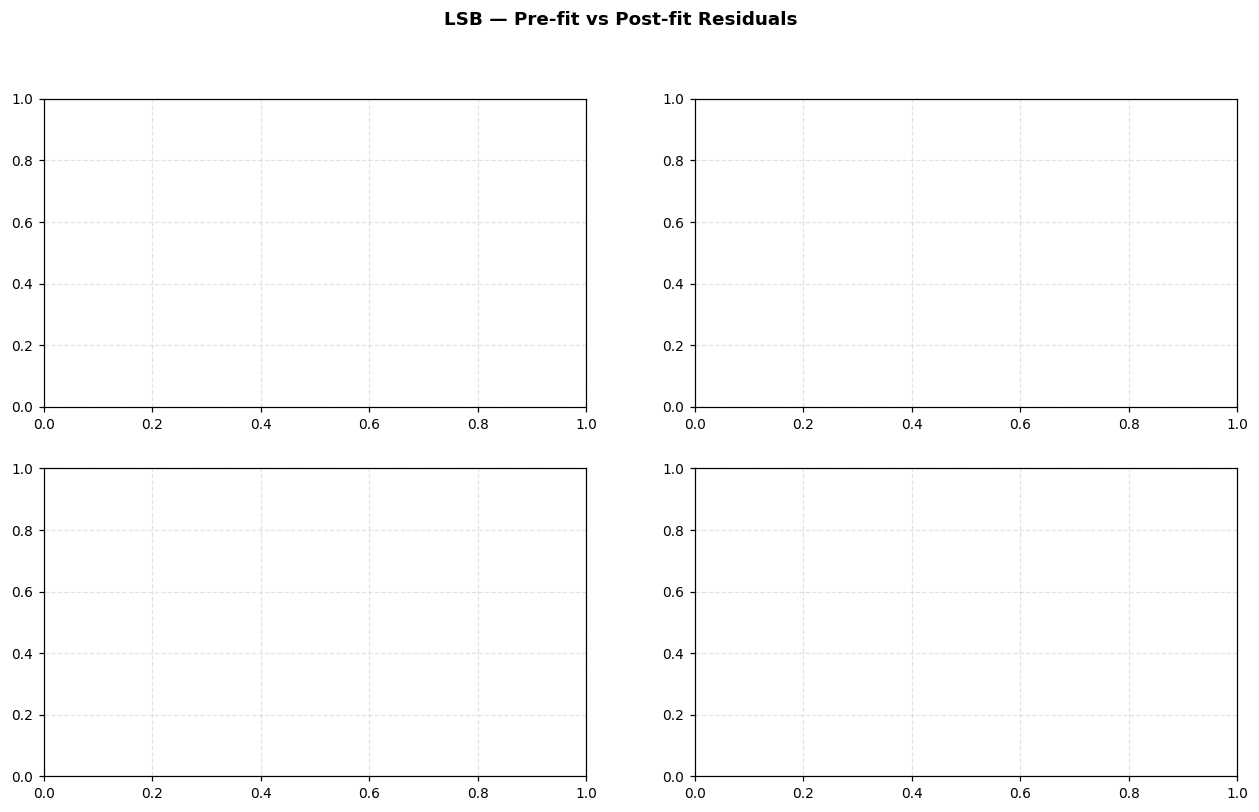

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("LSB — Pre-fit vs Post-fit Residuals", fontsize=12, fontweight="bold")

for row, (ds_name, sigma_val, ylabel) in enumerate([
    ("GS1 Range",     float(range_sigma.values) * 1e3,     "Range residual [m]"),
    ("GS1 RangeRate", float(rangerate_sigma.values) * 1e6, "RangeRate residual [mm/s]"),
]):
    scale = 1e3 if row == 0 else 1e6
    t_pre, r_pre, t_post, r_post = resid_from_filter(lsb, ds_name)
    for col, (t_r, r_r, label) in enumerate(
        [(t_pre, r_pre, "Pre-fit"), (t_post, r_post, "Post-fit")]
    ):
        ax = axes[row, col]
        if len(t_r):
            ax.plot(et2dt(t_r), r_r * scale, ".", ms=8,
                    color=COLORS[row * 2 + col], alpha=0.7, label=label)
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.axhline( 3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7, label="±3σ")
            ax.axhline(-3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7)
        ax.set_title(f"{ds_name} — {label}")
        ax.set_ylabel(ylabel); ax.set_xlabel("Calendar Date [UTC]")
        fmt_cal(ax); ax.legend()

plt.tight_layout(); plt.show()


## 8. Batch Filter: SRIFB + Static Parameter Estimation (η_SRP)

### Theory
The **SRIF Batch (SRIFB)** is the numerically superior square-root formulation of the batch filter.
Instead of accumulating the normal matrix **H^T W H** (which can become ill-conditioned), it works
with the square root of the information matrix **R̄** via QR decomposition.

### Static Parameter Estimation
The OD state can include **static scalar parameters** that do not propagate through dynamics but
affect the measurements through their force model coupling.

A common example is the **SRP scale factor η_SRP**: if our cannonball model is imperfect
(wrong area or reflectivity), η_SRP absorbs the mismatch.

```
F_SRP_corrected = η_SRP × F_SRP_nominal
```

The filter simultaneously estimates η_SRP alongside the 6-state trajectory.

### Estimation vs. Considered Parameters
- **`estimation='estimated'`** — parameter is fully solved for; its covariance shrinks with data.
- **`estimation='considered'`** — parameter is *not* solved for, but its uncertainty propagates
  into the state covariance (conservative covariance inflation without biasing the solve-for state).


In [13]:
# ── spacecraft with η_SRP in state ──────────────────────────────
Orbiter_srifb = scb.Spacecraft('Orbiter_SRIFB', -1002,
                                dry_mass+fuel_mass, area, cr)

# Slightly wrong η (true=1.0, reference=1.02 → 2% SRP model error)
eta_true = 1.0
eta_ref  = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1.02]), None), None)

pos_ref_srifb = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ref_srifb = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_srifb = (
    scb.StateDefinition()
    .position(Orbiter_srifb, pos_ref_srifb)
    .velocity(Orbiter_srifb, vel_ref_srifb)
    .param('eta_srp', Orbiter_srifb, eta_ref,
           estimation='estimated', dynamics='static')  # solve-for parameter
)
sv_srifb = scb.StateArray(epoch=epoch_0, origin=origin, state=state_srifb)

# ── force model for reference ─────────────────────────────────────
fm_srifb = scb.ForceModelTranslation(
    primary_body   = Orbiter_srifb,
    third_bodies   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP = True,
)
prop_srifb = scb.Propagator(
    primary_body = Orbiter_srifb,
    state_vector = sv_srifb,
    tspan        = epoch_array,
    force_models = fm_srifb,
)

# ── extended covariance (6 kinematic + 1 η) ─────────────────────
eta_sig   = scb.ArrayWUnits(np.array([0.1]), None)  # ±10% prior on η
cov_srifb = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig, eta_sig],
    epoch_array[1],
    from_list=True,
)

# ── measurement models need the state definition ─────────────────
Range_GS1_srifb     = scb.RangeIdeal('GS1 Range SRIFB', GS1,
                                      sigma=range_sigma,
                                      state_definition=state_srifb)
RangeRate_GS1_srifb = scb.RangeRateIdeal('GS1 RR SRIFB', GS1,
                                          sigma=rangerate_sigma,
                                          state_definition=state_srifb)

meas_list_srifb = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_srifb,     'observed_meas': obs_range_GS1, 'dataset_name': 'GS1 Range'},
    {'model': RangeRate_GS1_srifb, 'observed_meas': obs_rr_GS1,   'dataset_name': 'GS1 RangeRate'},
])

# ── instantiate SRIFB ────────────────────────────────────────────
ref_spk_srifb = 'data/kernels/scenario/batch_orbiter_ref_srifb.bsp'
if os.path.isfile(ref_spk_srifb): os.remove(ref_spk_srifb)

srifb = scb.SRIFB(
    propagator   = prop_srifb,
    settings     = scb.FilterSettings(
        initial_covariance = cov_srifb,
        output             = scb.OutputSettings(
            metadata = {'filter': 'SRIFB', 'params': 'eta_srp'}),
    ),
    measurements = meas_list_srifb,
    traj_name    = 'batch_orbiter_ref_srifb.bsp',
)

print("Running SRIFB batch filter with η_SRP estimation ...")
solution_srifb, n_iters_srifb, converged_srifb = srifb.fit(
    max_iterations       = 10,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'batch_orbiter_ref.bsp',
)
print(f"\nConverged: {converged_srifb}  after {n_iters_srifb} iteration(s)")


NameError: name 'pos_0' is not defined

In [14]:
# ── SRIFB — parameter estimation + state errors ──────────────────
dev_srifb   = solution_srifb.map_state_deviation_to_epoch()
eta_ref_val = float(eta_ref.quantity.values)
print(f"Estimated η_SRP deviation  : {dev_srifb[6]:.6f}  "
      f"(true error was {eta_ref_val - eta_true:.4f})")
print(f"Estimated position  dev [km]  : {dev_srifb[:3]}")
print(f"Estimated velocity  dev [km/s]: {dev_srifb[3:6]}")

# ── custom state-error plot using estimated_trajectory + propagate_covariance ─
meas_ep_sb = scb.EpochArray(solution_srifb.timestamps, sys='TDB')

est_pos_sb, est_vel_sb, est_eta = solution_srifb.estimated_trajectory(meas_ep_sb)

true_pos_sb = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_sb[k])['position'].values)
    for k in range(len(solution_srifb.timestamps))
])
true_vel_sb = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_sb[k])['velocity'].values)
    for k in range(len(solution_srifb.timestamps))
])

err_pos_sb = (est_pos_sb - true_pos_sb) * 1e3    # km → m
err_vel_sb = (est_vel_sb - true_vel_sb) * 1e6    # km/s → mm/s

P_sb      = solution_srifb.propagate_covariance(meas_ep_sb)
sig_pos_sb = np.array([np.sqrt(np.diag(P)[:3]) for P in P_sb]) * 1e3
sig_vel_sb = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_sb]) * 1e6

dts_sb = et2dt(solution_srifb.timestamps)
comp   = ['x', 'y', 'z']

fig, axes =  plt.subplots(2, 3, figsize=(14, 7), sharex=True)
fig.suptitle('SRIFB — Estimated Trajectory Error  (truth − estimate,  ±3σ band)\n'
             f'η_SRP est. deviation = {dev_srifb[6]:.6f}  '
             f'(true error = {eta_ref_val - eta_true:.4f})',
             fontweight='bold', fontsize=11)

for j in range(3):
    for row, (err, sig, unit, col) in enumerate([
        (err_pos_sb[:, j], sig_pos_sb[:, j], 'm',    'steelblue'),
        (err_vel_sb[:, j], sig_vel_sb[:, j], 'mm/s', 'tomato'),
    ]):
        ax = axes[row, j]
        ax.plot(dts_sb, err, '.', color=col, ms=3)
        ax.fill_between(dts_sb, -3*sig, 3*sig, alpha=0.25, color=col, label='±3σ')
        ax.axhline(0, color='k', lw=0.5, ls='--')
        lbl = f'Pos {comp[j]}' if row == 0 else f'Vel {comp[j]}'
        ax.set_title(lbl); ax.set_ylabel(f'Error [{unit}]')
        fmt_cal(ax)
        if j == 0: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

rms_pos_sb = np.sqrt(np.mean(err_pos_sb**2))
rms_vel_sb = np.sqrt(np.mean(err_vel_sb**2))
print(f"\nRMS position error : {rms_pos_sb:.2f} m")
print(f"RMS velocity error : {rms_vel_sb:.4f} mm/s")


NameError: name 'solution_srifb' is not defined

#### Enhanced: SRIFB — Final Covariance Corner Plot (pos + vel + η_SRP, 7×7)

The 7th state element is the estimated η_SRP correction.  Its correlation with the
velocity and position components reveals the coupling between SRP modelling errors
and orbit geometry that the filter is resolving.


In [15]:
t_final_sb  = float(solution_srifb.timestamps[-1])
ep_final_sb = scb.EpochArray(np.array([t_final_sb]), sys='TDB')
P_final_sb  = solution_srifb.propagate_covariance(ep_final_sb)[0]
labels7     = ["x", "y", "z", "vx", "vy", "vz", "η_SRP"]
fig = corner_cov(P_final_sb, labels7,
                 title="SRIFB — Final State Covariance (6 kinematic + η_SRP)",
                 figsize=(10, 9))
plt.show()


NameError: name 'solution_srifb' is not defined

## 9. Stochastic Acceleration: Piecewise Gauss-Markov (PFOGM)

### Theory
When unmodelled non-gravitational accelerations exist, we can augment the state with **stochastic acceleration
parameters** that are solved for alongside the trajectory.

**Piecewise FOGM (PFOGM)** divides the tracking arc into $N_b$ batches of length $\Delta T$.
Within each batch, the stochastic acceleration follows a
first-order Gauss–Markov process, while different batches are treated as uncorrelated.
This introduces $3N_b$ additional stochastic acceleration parameters into the estimation problem.

### When to use PFOGM vs. SNC
- **PFOGM (batch)**: Use when you want to *estimate* the unmodelled acceleration in each time
  interval as a deterministic parameter. Residuals should show flat, white-noise character after.
- **SNC (sequential)**: Use when you want the filter to *absorb* process noise in real time
  without adding to the state dimension. More appropriate for sequential estimators (next notebook).

### Parameter naming convention
- `a_fogm`  → 3-component first-order Gauss-Markov acceleration (continuous FOGM)
- `a_pfogm` → 3×N_batches piecewise-constant acceleration vector


In [16]:
# ── PFOGM configuration ──────────────────────────────────────────
batch_length = 6 * 3600.0                            # 6-hour batch intervals [s]
n_batches    = int(np.ceil((time_f - time_0) / batch_length))
print(f"PFOGM: {n_batches} batches of {batch_length/3600:.1f} hr each")

Orbiter_pfogm = scb.Spacecraft('Orbiter_PFOGM', -1003,
                                dry_mass+fuel_mass, area, cr)

# Initial stochastic acceleration reference (all zero = assume no unmodelled force)
a0_pfogm = scb.ArrayWFrame(
    np.zeros(3 * n_batches), km/sec**2, J2000
)

# Perturbed IC for the reference trajectory
pos_pfogm = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_pfogm = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_pfogm = (
    scb.StateDefinition()
    .position(Orbiter_pfogm, pos_pfogm)
    .velocity(Orbiter_pfogm, vel_pfogm)
    .param('a_pfogm', Orbiter_pfogm, a0_pfogm, dynamics='dynamic')
)
sv_pfogm = scb.StateArray(epoch=epoch_0, origin=origin, state=state_pfogm)

# Force model must declare PFOGM
beta_pfogm = np.array([1/3600, 1/3600, 1/3600])   # correlation: 1 hr in each axis
fm_pfogm = scb.ForceModelTranslation(
    primary_body                   = Orbiter_pfogm,
    third_bodies                   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP                 = True,
    piecewise_first_order_gauss_markov = True,
    pfogm_batch_length             = batch_length,
    pfogm_n_batches                = n_batches,
    pfogm_beta                     = beta_pfogm,
    t0                             = epoch_array[0],
)
prop_pfogm = scb.Propagator(
    primary_body = Orbiter_pfogm,
    state_vector = sv_pfogm,
    tspan        = epoch_array,
    force_models = fm_pfogm,
)

# ── extended covariance (6 + 3×N_b) ─────────────────────────────
a_sig = scb.ArrayWUnits(1e-10, km/sec**2)   # prior on each stochastic acc component
cov_pfogm = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig] + [a_sig] * (3 * n_batches),
    epoch_array[1],
    from_list=True,
)

# ── measurement list with PFOGM state definition ─────────────────
Range_GS1_pf = scb.RangeIdeal('GS1 Range PFOGM', GS1,
                                sigma=range_sigma, state_definition=state_pfogm)
RR_GS1_pf    = scb.RangeRateIdeal('GS1 RR PFOGM', GS1,
                                   sigma=rangerate_sigma, state_definition=state_pfogm)

meas_pfogm = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_pf, 'observed_meas': obs_range_GS1, 'dataset_name': 'GS1 Range'},
    {'model': RR_GS1_pf,    'observed_meas': obs_rr_GS1,   'dataset_name': 'GS1 RangeRate'},
])

# ── run PFOGM batch OD (using LSB) ───────────────────────────────
ref_spk_pf = 'data/kernels/scenario/batch_orbiter_ref_pfogm.bsp'
if os.path.isfile(ref_spk_pf): os.remove(ref_spk_pf)

lsb_pfogm = scb.LSB(
    propagator   = prop_pfogm,
    settings     = scb.FilterSettings(
        initial_covariance = cov_pfogm,
        output             = scb.OutputSettings(metadata={'filter':'LSB-PFOGM'}),
    ),
    measurements = meas_pfogm,
    traj_name    = 'batch_orbiter_ref_pfogm.bsp',
)
print("Running PFOGM batch OD ...")
sol_pfogm, ni_pf, conv_pf = lsb_pfogm.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='batch_orbiter_ref.bsp',
)
print(f"\nConverged: {conv_pf} after {ni_pf} iterations")


NameError: name 'time_f' is not defined

In [17]:
# ── PFOGM — state errors ─────────────────────────────────────────
meas_ep_pf = scb.EpochArray(sol_pfogm.timestamps, sys='TDB')
est_pos_pf, est_vel_pf, est_acc_pf = sol_pfogm.estimated_trajectory(meas_ep_pf)

true_pos_pf = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_pf[k])['position'].values)
    for k in range(len(sol_pfogm.timestamps))
])
true_vel_pf = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_pf[k])['velocity'].values)
    for k in range(len(sol_pfogm.timestamps))
])

err_pos_pf = (est_pos_pf - true_pos_pf) * 1e3
err_vel_pf = (est_vel_pf - true_vel_pf) * 1e6
P_pf       = sol_pfogm.propagate_covariance(meas_ep_pf)
sig_pos_pf = np.array([np.sqrt(np.diag(P)[:3]) for P in P_pf]) * 1e3
sig_vel_pf = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_pf]) * 1e6
dts_pf     = et2dt(sol_pfogm.timestamps)
comp       = ['x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
fig.suptitle('PFOGM Batch OD — Estimated Trajectory Error  ±3σ',
             fontweight='bold', fontsize=11)
for j in range(3):
    for row, (err, sig, unit, col) in enumerate([
        (err_pos_pf[:, j], sig_pos_pf[:, j], 'm',    'steelblue'),
        (err_vel_pf[:, j], sig_vel_pf[:, j], 'mm/s', 'tomato'),
    ]):
        ax = axes[row, j]
        ax.plot(dts_pf, err, '.', color=col, ms=3)
        ax.fill_between(dts_pf, -3*sig, 3*sig, alpha=0.25, color=col, label='±3σ')
        ax.axhline(0, color='k', lw=0.5, ls='--')
        lbl = f'Pos {comp[j]}' if row == 0 else f'Vel {comp[j]}'
        ax.set_title(lbl); ax.set_ylabel(f'Error [{unit}]')
        fmt_cal(ax)
        if j == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── PFOGM — stochastic accelerations (candlestick: ±1σ body, ±2σ whiskers) ──
from matplotlib.patches import Rectangle
from matplotlib.dates   import date2num

dev_pfogm = sol_pfogm.map_state_deviation_to_epoch()
a_est     = dev_pfogm[6:].reshape(n_batches, 3) * 1e9   # km/s² → nm/s²

# PFOGM is a batch filter: acceleration estimates are global constants.
# Their uncertainty lives in the final covariance matrix — no propagation needed.
P_final = sol_pfogm.covariance_est[-1]
n_state = P_final.shape[0]
sig_acc = np.zeros((n_batches, 3))
for k in range(n_batches):
    idx = 6 + 3*k
    if idx + 3 <= n_state:
        sig_acc[k] = np.sqrt(np.maximum(np.diag(P_final)[idx : idx+3], 0)) * 1e9
    else:
        sig_acc[k] = np.sqrt(np.maximum(np.diag(P_final)[6:9], 0)) * 1e9

batch_centres = [et2dt([time_0 + (k + 0.5) * batch_length])[0] for k in range(n_batches)]
comp_a  = ['aₓ (J2000)', 'aᵧ (J2000)', 'a_z (J2000)']
palette = ['steelblue', 'tomato', 'seagreen']
hw      = (batch_length / 86400) * 0.35   # half-bar width [matplotlib date days]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('PFOGM — Stochastic Acceleration Estimates per Batch [nm/s²]\n'
             'box = ±1σ  |  whisker caps = ±2σ  |  centre mark = estimate',
             fontweight='bold', fontsize=11)

for c in range(3):
    ax = axes[c]
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)

    for k in range(n_batches):
        xc = date2num(batch_centres[k])
        a  = a_est[k, c]
        s1 = sig_acc[k, c]
        s2 = 2.0 * s1

        # wick: a-2σ to a+2σ
        ax.plot([xc, xc], [a - s2, a + s2],
                color='k', lw=1.0, zorder=2, solid_capstyle='butt')

        # caps at ±2σ
        cap = hw * 0.55
        ax.plot([xc-cap, xc+cap], [a+s2, a+s2], 'k-', lw=0.9, zorder=2)
        ax.plot([xc-cap, xc+cap], [a-s2, a-s2], 'k-', lw=0.9, zorder=2)

        # body: ±1σ (filled rectangle)
        ax.add_patch(Rectangle(
            (xc - hw, a - s1), 2*hw, 2*s1,
            facecolor=palette[c], edgecolor='navy',
            linewidth=0.8, alpha=0.85, zorder=3,
        ))

        # centre mark (estimated value)
        ax.plot([xc - hw, xc + hw], [a, a], 'k-', lw=1.8, zorder=4)

    # y-limits with padding around data + uncertainty
    lo = np.min(a_est[:, c] - 2.2*sig_acc[:, c])
    hi = np.max(a_est[:, c] + 2.2*sig_acc[:, c])
    pad = max(abs(hi - lo) * 0.15, 0.5)
    lo = min(lo - pad, -pad); hi = max(hi + pad, pad)
    ax.set_ylim(lo, hi)
    ax.set_ylabel(f'{comp_a[c]} [nm/s²]', fontsize=9)
    fmt_cal(ax)

plt.tight_layout(); plt.show()


NameError: name 'sol_pfogm' is not defined

## 10. Measurement Editing

**Measurement editing** (also called *data editing* or *outlier rejection*) removes corrupted or
anomalous observations before they degrade the OD solution.

Scarabaeus supports three editing strategies configurable via `FilterSettings`:

### 10.1 Chi-Squared Filter (automatic, recommended)
For each observation, compute the normalised residual

$$\chi_i^2 = \frac{(y_i - \hat{y}_i)^2}{\sigma_i^2}$$

If $\chi_i > \sigma_\text{scale}$ (default 3), the measurement is flagged as an outlier.
This is the standard 3-σ editing used in operational OD.

```python
settings = scb.FilterSettings(
    initial_covariance = cov,
    editing_method     = 'chi2',
    editing_kwargs     = {'sigma_scale': 3.0},
    ...
)
```

### 10.2 Date-Range Filter (manual)
Remove all measurements outside a specified UTC time window:

```python
settings = scb.FilterSettings(
    editing_method = 'date_range',
    editing_kwargs = {'start': t_start_et, 'end': t_end_et},
    ...
)
```

### 10.3 Lasso Selector (interactive)
Opens a matplotlib figure where the analyst can draw a lasso to select outliers:

```python
settings = scb.FilterSettings(
    editing_method = 'lasso',
    editing_kwargs = {'sigma_scale': 3.0, 'preview': True},
    ...
)
```



In [18]:
# ── inject outliers into the range measurements ──────────────────
# Extract the raw numpy values, corrupt them, then rebuild the ArrayWFrame.
# ArrayWFrame doesn't support in-place index assignment, so we work on the
# underlying numpy array and reconstruct.
rng_seed    = np.random.RandomState(42)
raw_vals    = np.array(obs_range_GS1[2].quantity.values, dtype=float)  # km
outlier_idx = rng_seed.choice(len(raw_vals), 5, replace=False)
raw_vals[outlier_idx] += rng_seed.uniform(-50, 50, size=5)

vals_with_outliers = scb.ArrayWFrame(scb.ArrayWUnits(raw_vals, km), frame)
# preserve all 4 tuple elements: (epoch_array, times_sec, values, outlier_flag)
obs_range_edited = (obs_range_GS1[0], obs_range_GS1[1],
                    vals_with_outliers, obs_range_GS1[3])

print(f"Injected outliers at indices: {sorted(outlier_idx.tolist())}")

# ── filter with chi-squared editing ──────────────────────────────
Orbiter_ed = scb.Spacecraft('Orbiter_Edit', -1004, dry_mass+fuel_mass, area, cr)
pos_ed = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ed = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_ed = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter_ed, pos_ed),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter_ed, vel_ed),
])
sv_ed = scb.StateArray(epoch=epoch_0, origin=origin, state=state_ed)
fm_ed = scb.ForceModelTranslation(primary_body=Orbiter_ed,
                                   third_bodies=['MERCURY', 'VENUS', 'EARTH'],
                                   cannonball_SRP=True)
prop_ed = scb.Propagator(primary_body=Orbiter_ed, state_vector=sv_ed,
                          tspan=epoch_array, force_models=fm_ed)

Range_GS1_ed = scb.RangeIdeal('GS1 Range Edited', GS1, sigma=range_sigma)
meas_ed = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1_ed,  observed_meas=obs_range_edited,
                        dataset_name='GS1 Range (w/ outliers)'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr_GS1,
                        dataset_name='GS1 RangeRate'),
)

ref_spk_ed = 'data/kernels/scenario/batch_orbiter_ref_edit.bsp'
if os.path.isfile(ref_spk_ed): os.remove(ref_spk_ed)

lsb_ed = scb.LSB(
    propagator   = prop_ed,
    settings     = scb.FilterSettings(
        initial_covariance = state_cov,
        editing_method     = 'lasso',
        output             = scb.OutputSettings(metadata={'filter': 'LSB-lasso-editing'}),
    ),
    measurements = meas_ed,
    traj_name    = 'batch_orbiter_ref_edit.bsp',
)
print("Running LSB with lasso editing ...")
sol_ed, ni_ed, conv_ed = lsb_ed.fit(
    max_iterations        = 1,
    convergence_threshold = 1e-6,
    verbose               = True,
    traj_name             = 'batch_orbiter_ref_edit.bsp',
)
print(f"Converged: {conv_ed} after {ni_ed} iterations")


NameError: name 'obs_range_GS1' is not defined

## 11. Saving the OD Solution

`OutputSettings` controls what the filter saves and where.

```python
scb.OutputSettings(
    solution_output_path = 'results/',      # directory
    solution_output_name = 'batch_od_run1', # filename stem
    save_deviation_est   = True,            # state deviation at each epoch
    save_state_est       = True,            # absolute state estimates
    save_covariance_est  = True,            # estimated covariance history
    save_prefits         = True,            # pre-fit residuals
    save_postfits        = True,            # post-fit residuals
    metadata             = {'version': '1.0'},
)
```

The `SolutionOD` object (returned by `filter.fit()`) provides access to all results
regardless of whether file output is configured.


In [19]:
# ═══════════════════════════════════════════════════════════════════
# SolutionOD API — estimated_trajectory, propagate_state, propagate_covariance
# ═══════════════════════════════════════════════════════════════════
solution = solution_lsb

t_arc_start = float(solution.timestamps[0])
t_arc_end   = float(solution.timestamps[-1])

# ── A. estimated_trajectory: pos/vel/params AT measurement epochs ─────────────
meas_epochs = scb.EpochArray(solution.timestamps, sys='TDB')
est_pos, est_vel, est_params = solution.estimated_trajectory(meas_epochs)

print("── A. estimated_trajectory ──────────────────────────────────")
print(f"  n epochs   : {len(solution.timestamps)}")
print(f"  est_pos  shape : {est_pos.shape}  first: {est_pos[0]}")
print(f"  est_vel  shape : {est_vel.shape}  first: {est_vel[0]}")
print(f"  est_params     : {'None' if est_params is None else est_params.shape}")

# ValueError guard: estimated_trajectory only valid at measurement epochs
try:
    solution.estimated_trajectory(
        scb.EpochArray(np.array([t_arc_end + 3600.0]), sys='TDB'))
    print("  FAIL — should have raised ValueError")
except ValueError:
    print("  PASS — correctly rejects non-measurement epochs")

# ── B. propagate_state: estimated state at ARBITRARY epochs ────────────────
t_inside = np.linspace(t_arc_start, t_arc_end, 8)          # 8 pts including arc end
t_after  = t_arc_end + np.linspace(1800, 6*3600, 8)        # 8 pts strictly after arc end
t_all    = np.concatenate([t_inside, t_after])              # 16 pts, no duplicate
ep_all   = scb.EpochArray(t_all, sys='TDB')

state_list = solution.propagate_state(ep_all)

# Extract pos / vel from each returned StateArray via values0
all_pos = np.array([np.asarray(sa.values0.values[:3]) for sa in state_list])
all_vel = np.array([np.asarray(sa.values0.values[3:6]) for sa in state_list])

print("── B. propagate_state ───────────────────────────────────────")
print(f"  propagated {len(state_list)} epochs (8 inside arc, 8 outside)")
print(f"  first inside pos  (km): {all_pos[0]}")
print(f"  first outside pos (km): {all_pos[8]}")

# ── C. propagate_covariance: P(t) inside AND outside the arc ──────────────
P_all    = solution.propagate_covariance(ep_all)
rss_sig  = np.array([np.linalg.norm(np.sqrt(np.maximum(np.diag(P)[:3], 0))) for P in P_all])

dts_all  = et2dt(t_all)
dts_arc  = et2dt([t_arc_start, t_arc_end])
n_in     = len(t_inside)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(dts_arc[0], dts_arc[1], alpha=0.10, color='green', label='Measurement arc')
ax.axvline(dts_arc[1], color='green', lw=1.2, ls='--')
ax.semilogy(dts_all[:n_in],   rss_sig[:n_in]   * 1e3, 'b.-', ms=5,
            lw=1.2, label='Inside arc — 1σ RSS (m)')
ax.semilogy(dts_all[n_in-1:], rss_sig[n_in-1:] * 1e3, 'r.-', ms=5,
            lw=1.2, label='After arc — propagated 1σ RSS (m)')
ax.set_xlabel('Calendar Date [UTC]')
ax.set_ylabel('Position 1-σ RSS [m]')
ax.set_title('Covariance: inside and beyond the measurement arc')
ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t_arc_start)
plt.tight_layout(); plt.show()

print("── C. propagate_covariance ──────────────────────────────────")
print(f"  1σ RSS at arc start : {rss_sig[0]*1e3:.2f} m")
print(f"  1σ RSS at arc end   : {rss_sig[n_in-1]*1e3:.2f} m")
print(f"  1σ RSS at +6 hr     : {rss_sig[-1]*1e3:.2f} m")


NameError: name 'solution_lsb' is not defined

## Summary

This notebook demonstrated the **complete batch OD workflow** in Scarabaeus:

| Step | Class/Function | Notes |
|------|---------------|-------|
| Spacecraft model | `scb.Spacecraft` | mass, area, CR |
| Dynamics | `scb.ForceModelTranslation` | Keplerian, 3-body, SRP (cannonball/N-plate), SpherHarm, FOGM, PFOGM |
| Dynamics tuning | Propagation comparison | Compare pos error vs fidelity |
| True trajectory | `scb.Propagator` + `scb.Trajectory` | Write SPK for truth |
| Measurements | `RangeIdeal`, `RangeRateIdeal`, `DopplerIdeal`, `DiffOneWayRangeIdeal` | All measurement models |
| Reference IC | Perturbed state + P₀ | `scb.CovarianceMatrix` |
| LSB batch filter | `scb.LSB` | Least-squares batch |
| SRIFB + η_SRP | `scb.SRIFB` + `.param('eta_srp', ...)` | Square-root batch + parameter |
| PFOGM | `.param('a_pfogm', ..., dynamics='dynamic')` | Stochastic acceleration |
| Measurement editing | `FilterSettings(editing_method='chi_squared')` | Outlier rejection |
| Solution analysis | `solution.estimated_trajectory()`, `.propagate_covariance()` | State + uncertainty |

**Next:** See `OD_Sequential_Demo.ipynb` for the sequential filter (LKF / SRIF) with SNC/DMC
process noise, RTS smoother, and multi-leg MissionSequence OD.
